In [2]:
# import sys
# !{sys.executable} -m pip install xgboost --break-system-packages

In [3]:
import xgboost
print(xgboost.__version__)

3.2.0


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier


In [5]:
df = pd.read_csv("/home/slave01/customer_churn_prediction/data/raw/ecommerce_customer_churn_dataset.csv")

In [6]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [7]:
df.shape

(50000, 25)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [9]:
df.describe()


,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [10]:
df.isnull().sum()


Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

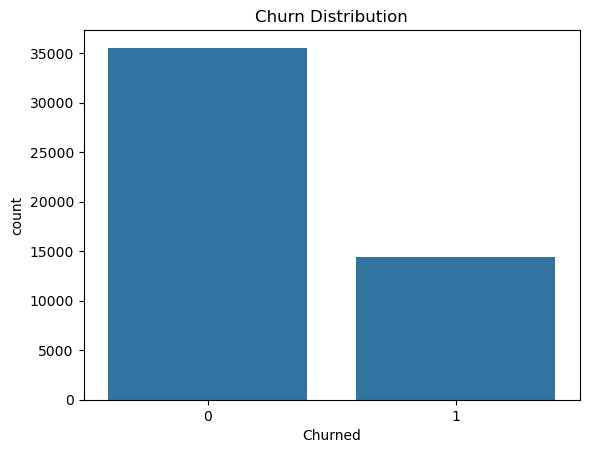

In [11]:
plt.figure()
sns.countplot(x="Churned", data=df)
plt.title("Churn Distribution")
plt.show()

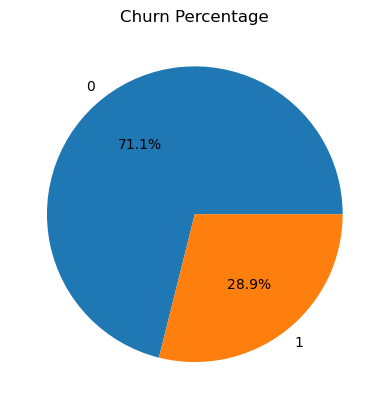

In [12]:
plt.figure()
df["Churned"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

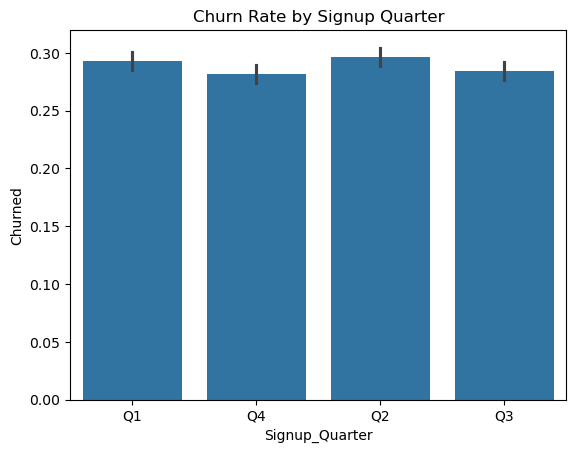

In [13]:
plt.figure()
sns.barplot(x="Signup_Quarter", y="Churned", data=df)
plt.title("Churn Rate by Signup Quarter")
plt.show()

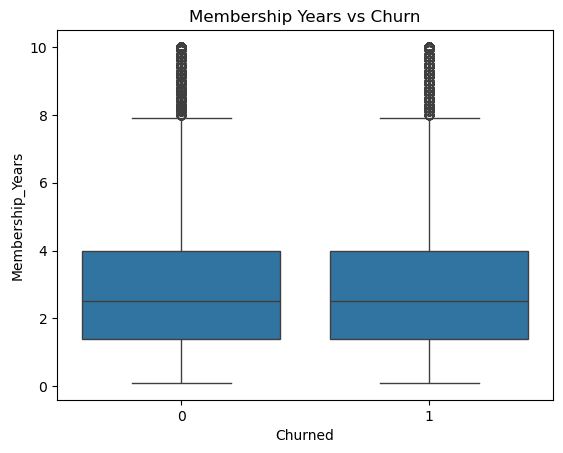

In [14]:
plt.figure()
sns.boxplot(x="Churned", y="Membership_Years", data=df)
plt.title("Membership Years vs Churn")
plt.show()

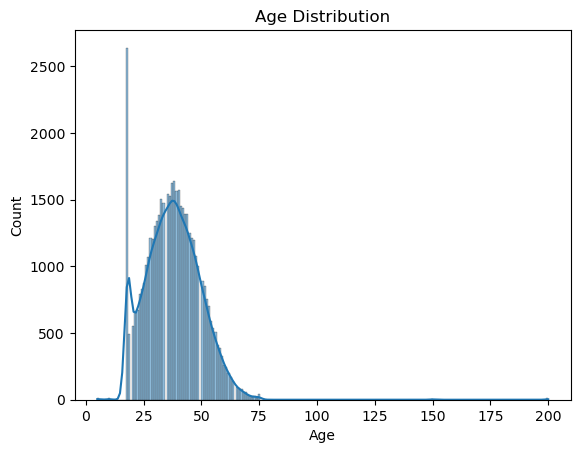

In [15]:
plt.figure()
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

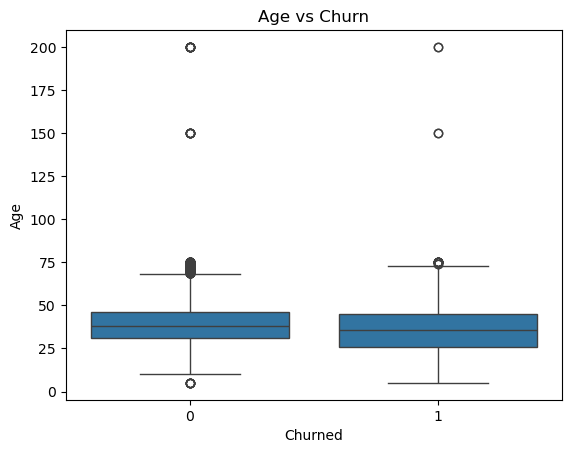

In [16]:
plt.figure()
sns.boxplot(x="Churned", y="Age", data=df)
plt.title("Age vs Churn")
plt.show()

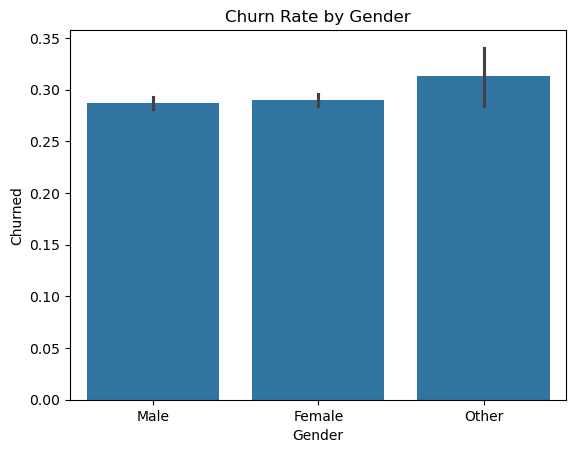

In [17]:
plt.figure()
sns.barplot(x="Gender", y="Churned", data=df)
plt.title("Churn Rate by Gender")
plt.show()

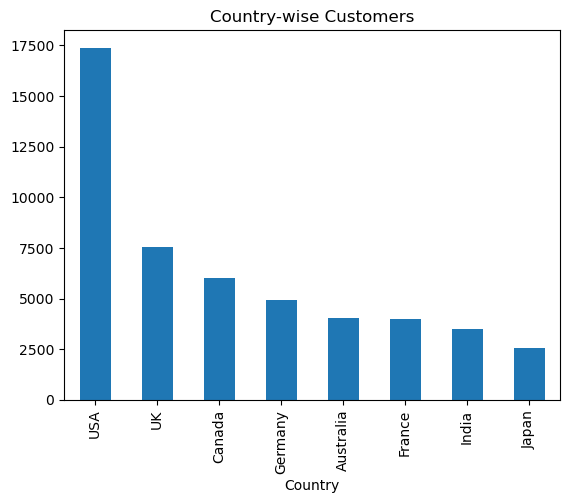

In [18]:
plt.figure()
df["Country"].value_counts().plot(kind="bar")
plt.title("Country-wise Customers")
plt.show()

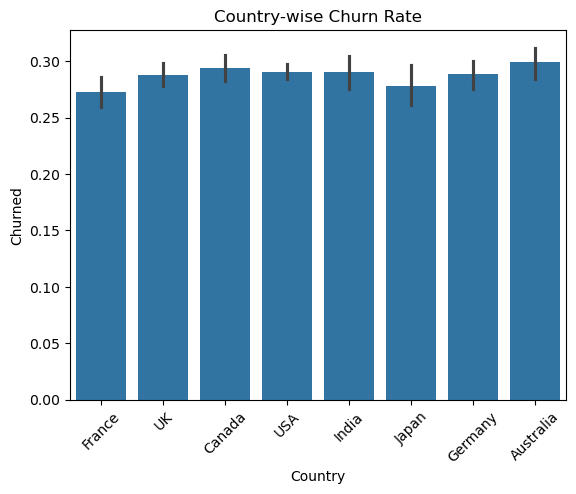

In [19]:
plt.figure()
sns.barplot(x="Country", y="Churned", data=df)
plt.title("Country-wise Churn Rate")
plt.xticks(rotation=45)
plt.show()

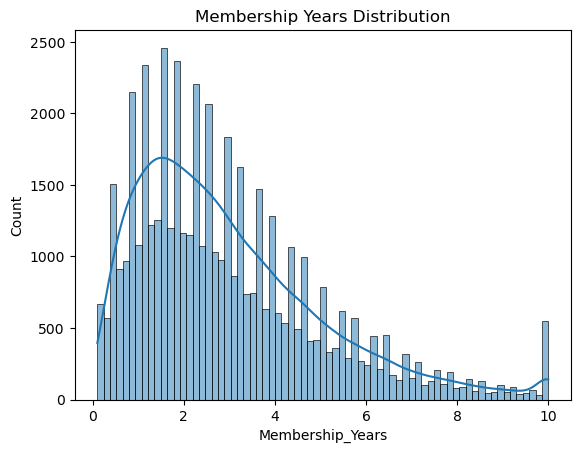

In [20]:
plt.figure()
sns.histplot(df["Membership_Years"], kde=True)
plt.title("Membership Years Distribution")
plt.show()

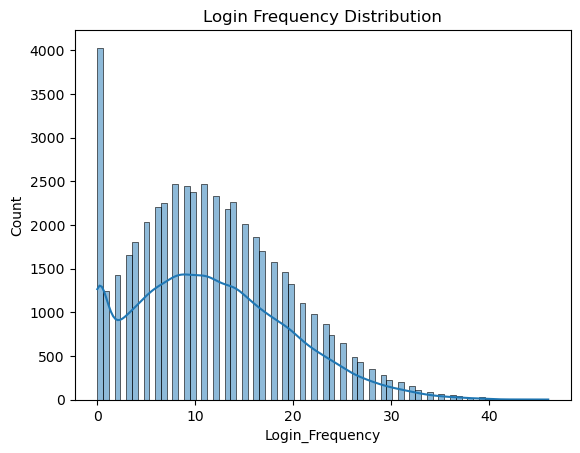

In [21]:
plt.figure()
sns.histplot(df["Login_Frequency"], kde=True)
plt.title("Login Frequency Distribution")
plt.show()

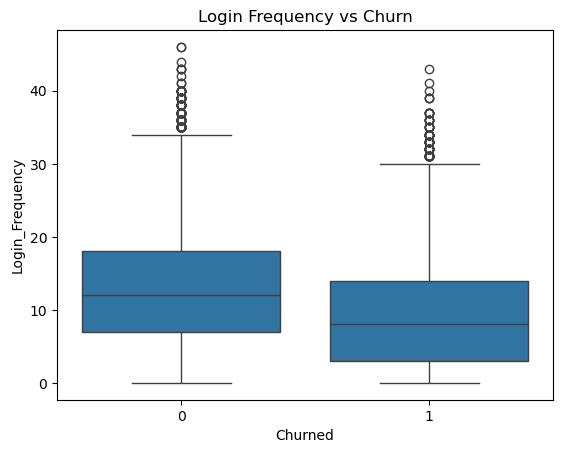

In [22]:
plt.figure()
sns.boxplot(x="Churned", y="Login_Frequency", data=df)
plt.title("Login Frequency vs Churn")
plt.show()

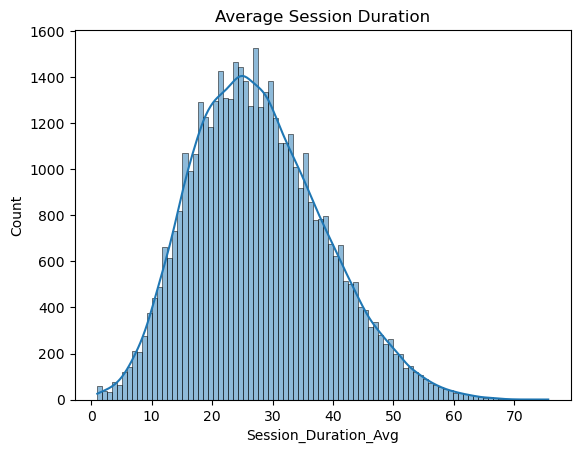

In [23]:
plt.figure()
sns.histplot(df["Session_Duration_Avg"], kde=True)
plt.title("Average Session Duration")
plt.show()

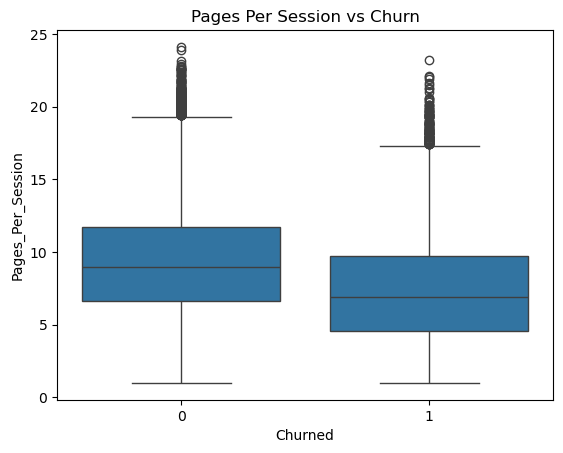

In [24]:
plt.figure()
sns.boxplot(x="Churned", y="Pages_Per_Session", data=df)
plt.title("Pages Per Session vs Churn")
plt.show()

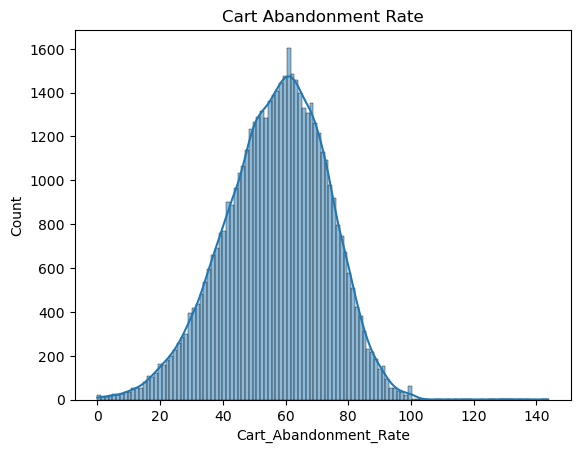

In [25]:
plt.figure()
sns.histplot(df["Cart_Abandonment_Rate"], kde=True)
plt.title("Cart Abandonment Rate")
plt.show()

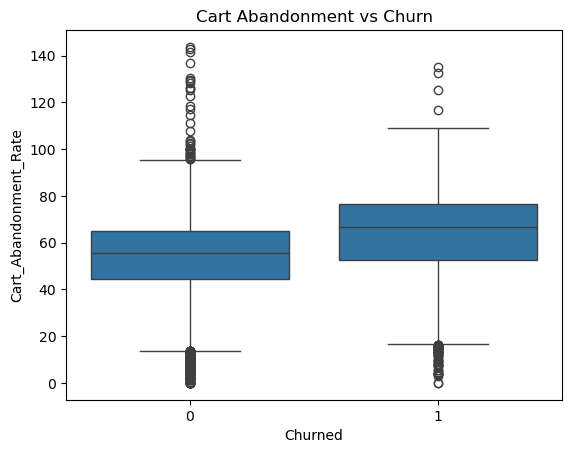

In [26]:
plt.figure()
sns.boxplot(x="Churned", y="Cart_Abandonment_Rate", data=df)
plt.title("Cart Abandonment vs Churn")
plt.show()

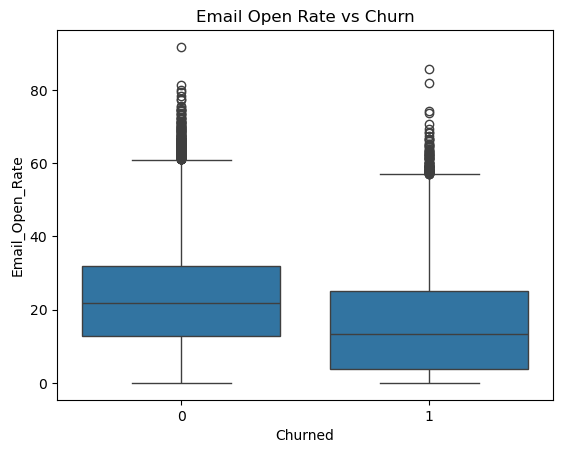

In [27]:
plt.figure()
sns.boxplot(x="Churned", y="Email_Open_Rate", data=df)
plt.title("Email Open Rate vs Churn")
plt.show()

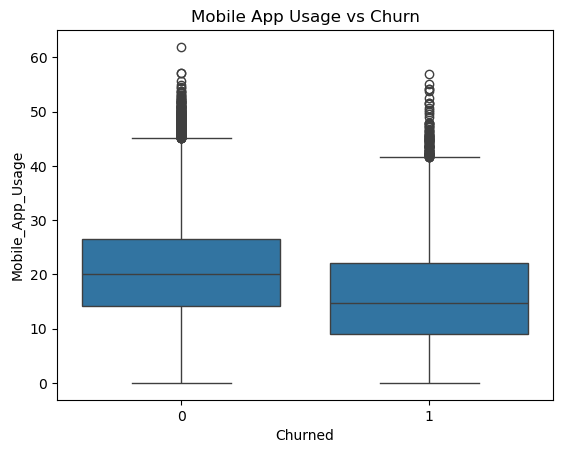

In [28]:
plt.figure()
sns.boxplot(x="Churned", y="Mobile_App_Usage", data=df)
plt.title("Mobile App Usage vs Churn")
plt.show()

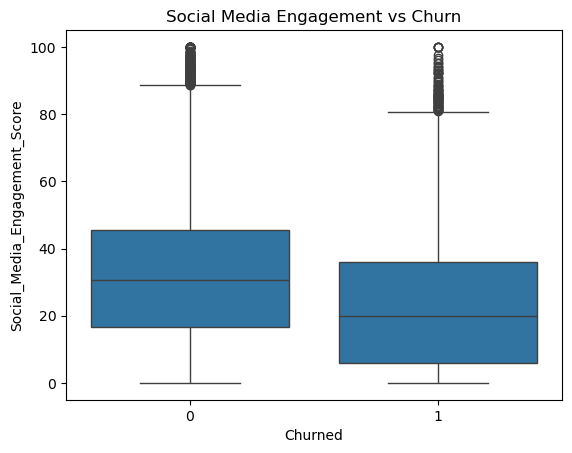

In [29]:
plt.figure()
sns.boxplot(x="Churned", y="Social_Media_Engagement_Score", data=df)
plt.title("Social Media Engagement vs Churn")
plt.show()

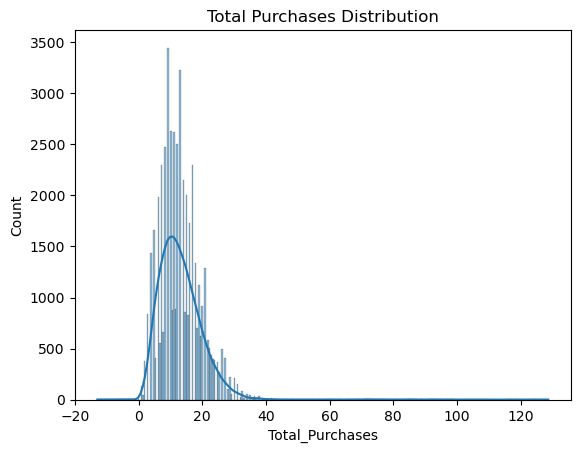

In [30]:
plt.figure()
sns.histplot(df["Total_Purchases"], kde=True)
plt.title("Total Purchases Distribution")
plt.show()

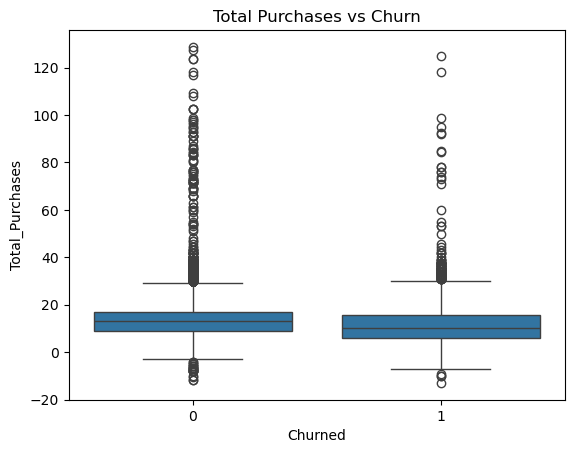

In [31]:
plt.figure()
sns.boxplot(x="Churned", y="Total_Purchases", data=df)
plt.title("Total Purchases vs Churn")
plt.show()

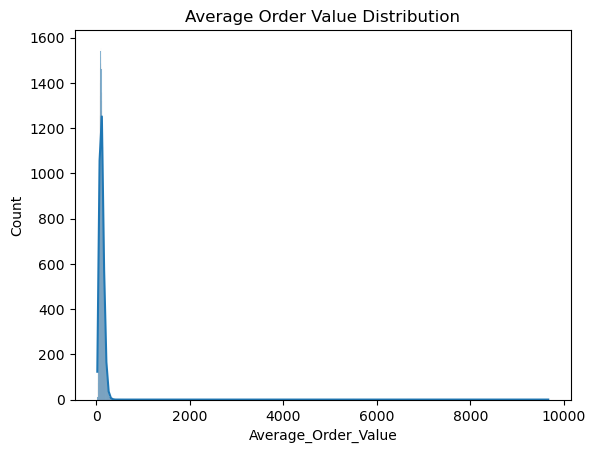

In [32]:
plt.figure()
sns.histplot(df["Average_Order_Value"], kde=True)
plt.title("Average Order Value Distribution")
plt.show()


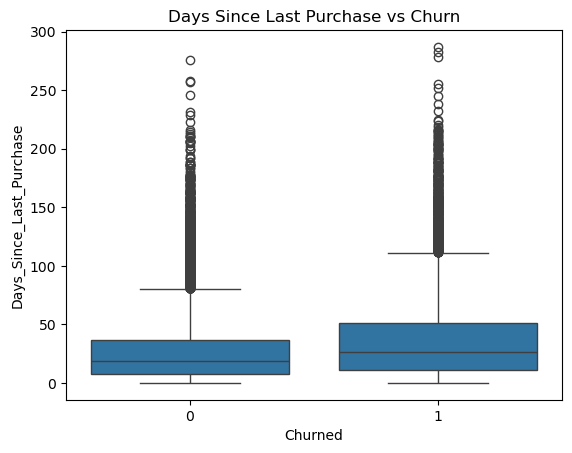

In [33]:
plt.figure()
sns.boxplot(x="Churned", y="Days_Since_Last_Purchase", data=df)
plt.title("Days Since Last Purchase vs Churn")
plt.show()

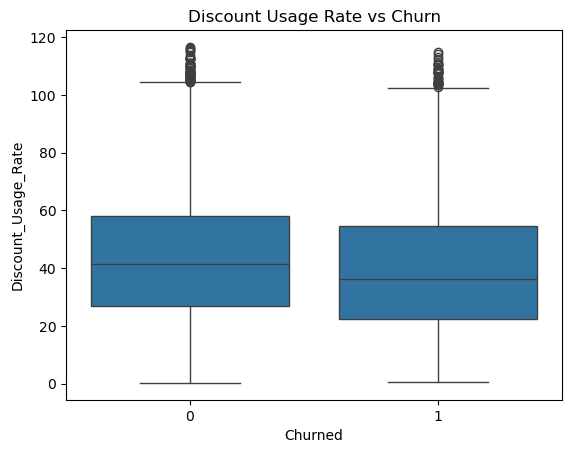

In [34]:
plt.figure()
sns.boxplot(x="Churned", y="Discount_Usage_Rate", data=df)
plt.title("Discount Usage Rate vs Churn")
plt.show()

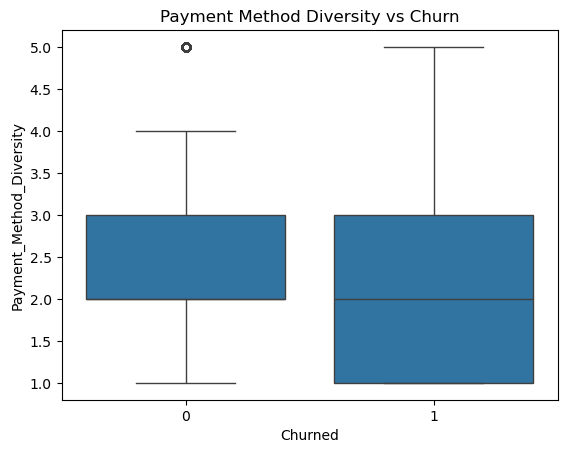

In [35]:
plt.figure()
sns.boxplot(x="Churned", y="Payment_Method_Diversity", data=df)
plt.title("Payment Method Diversity vs Churn")
plt.show()

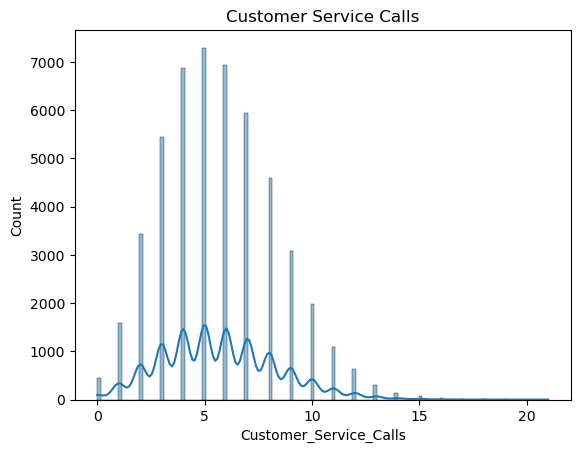

In [36]:
plt.figure()
sns.histplot(df["Customer_Service_Calls"], kde=True)
plt.title("Customer Service Calls")
plt.show()

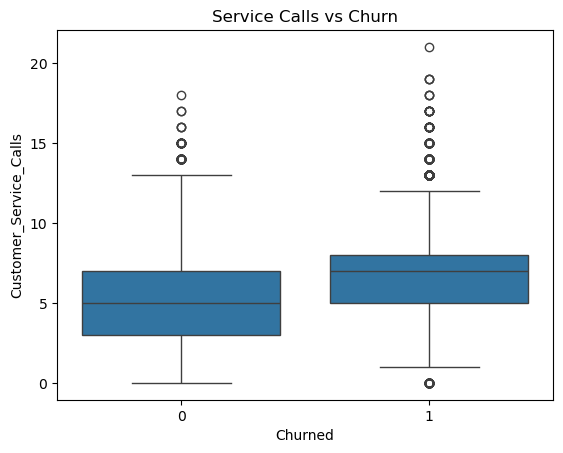

In [37]:
plt.figure()
sns.boxplot(x="Churned", y="Customer_Service_Calls", data=df)
plt.title("Service Calls vs Churn")
plt.show()

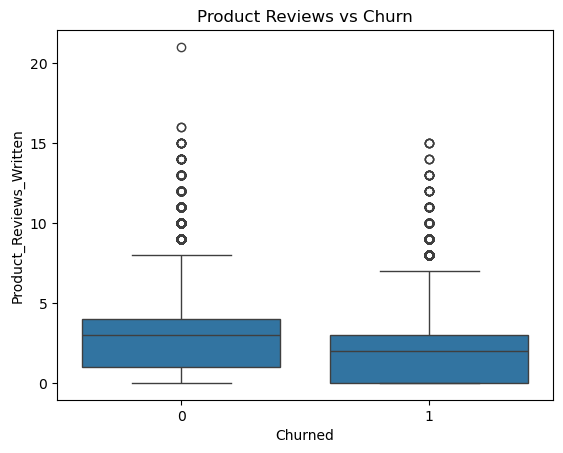

In [38]:
plt.figure()
sns.boxplot(x="Churned", y="Product_Reviews_Written", data=df)
plt.title("Product Reviews vs Churn")
plt.show()

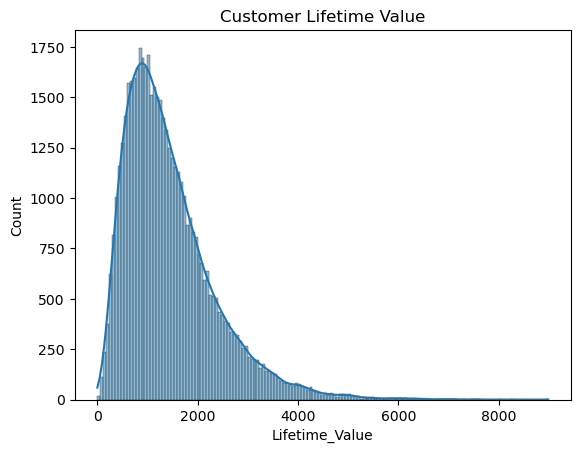

In [39]:
plt.figure()
sns.histplot(df["Lifetime_Value"], kde=True)
plt.title("Customer Lifetime Value")
plt.show()

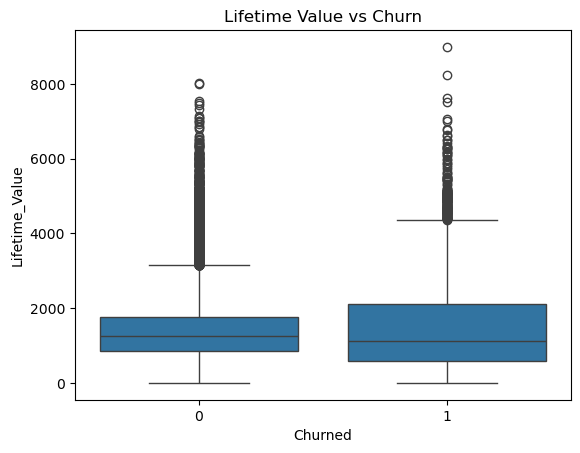

In [40]:
plt.figure()
sns.boxplot(x="Churned", y="Lifetime_Value", data=df)
plt.title("Lifetime Value vs Churn")
plt.show()

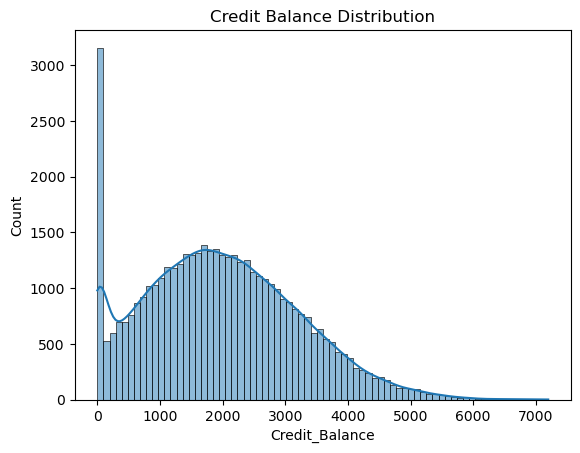

In [41]:
plt.figure()
sns.histplot(df["Credit_Balance"], kde=True)
plt.title("Credit Balance Distribution")
plt.show()

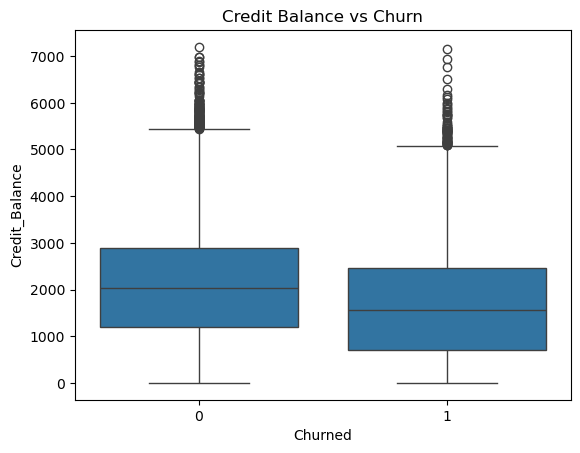

In [42]:
plt.figure()
sns.boxplot(x="Churned", y="Credit_Balance", data=df)
plt.title("Credit Balance vs Churn")
plt.show()

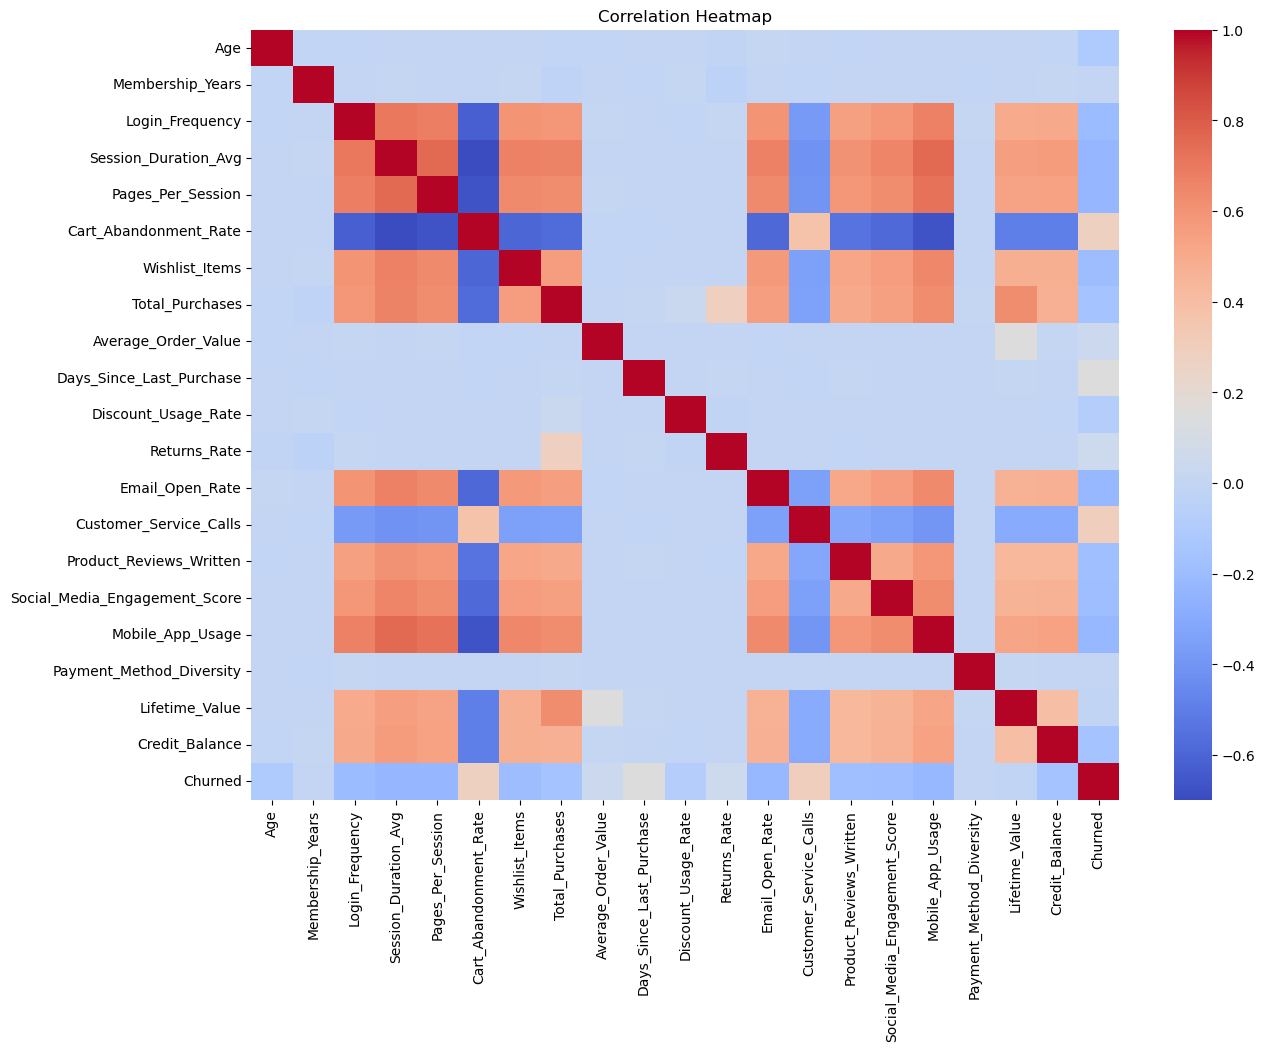

In [43]:
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

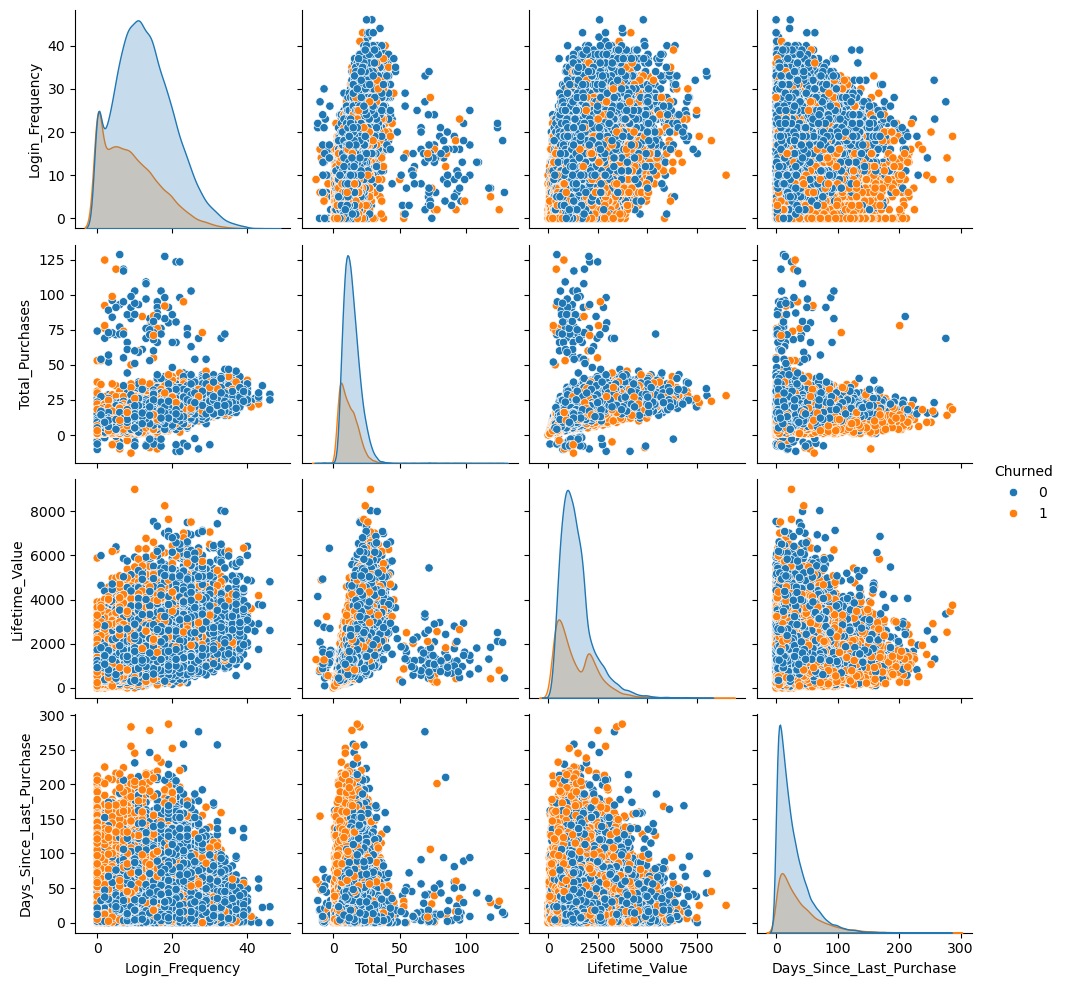

In [44]:
sns.pairplot(df[["Login_Frequency","Total_Purchases",
                 "Lifetime_Value","Days_Since_Last_Purchase","Churned"]],
             hue="Churned")
plt.show()

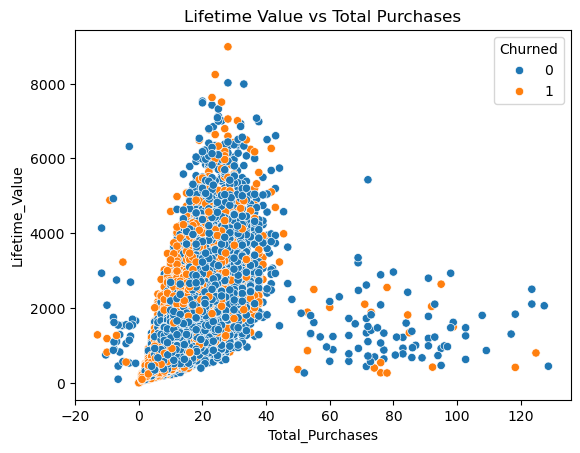

In [45]:
plt.figure()
sns.scatterplot(x="Total_Purchases", y="Lifetime_Value",
                hue="Churned", data=df)
plt.title("Lifetime Value vs Total Purchases")
plt.show()

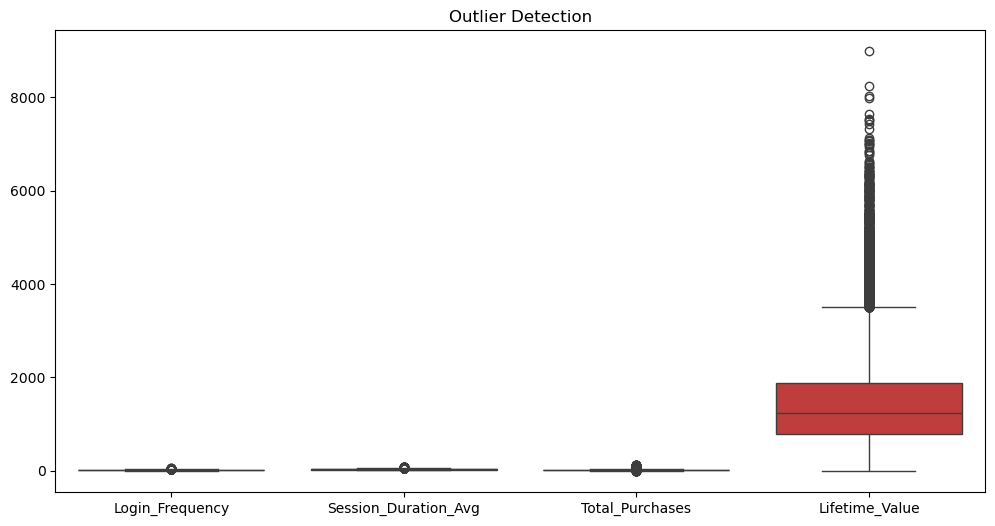

In [46]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[["Login_Frequency","Session_Duration_Avg",
                     "Total_Purchases","Lifetime_Value"]])
plt.title("Outlier Detection")
plt.show()

In [47]:
num_cols = [
    "Age",
    "Session_Duration_Avg",
    "Pages_Per_Session",
    "Wishlist_Items",
    "Days_Since_Last_Purchase",
    "Discount_Usage_Rate",
    "Returns_Rate",
    "Email_Open_Rate",
    "Customer_Service_Calls",
    "Product_Reviews_Written",
    "Social_Media_Engagement_Score",
    "Mobile_App_Usage",
    "Payment_Method_Diversity",
    "Credit_Balance"
]

In [48]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [49]:
num_cols = df.select_dtypes(include=np.number).columns.drop("Churned")

In [50]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))

In [51]:
cat_cols = df.select_dtypes(include=["object"]).columns


In [52]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [53]:
X = df.drop("Churned", axis=1)
y = df["Churned"]

In [54]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled, columns=X.columns)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [56]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Support Vector Machine": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

In [57]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

In [58]:
results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Gradient Boosting,0.91688,0.935954,0.764673,0.841688,0.926927
9,XGBoost,0.91480,0.905702,0.787099,0.842246,0.926422
2,Random Forest,0.91456,0.920357,0.771041,0.839108,0.923528
8,Extra Trees,0.87448,0.909747,0.627907,0.742998,0.914261
4,Support Vector Machine,0.86224,0.844891,0.640919,0.728904,0.893901
7,AdaBoost,0.83816,0.779066,0.614064,0.686794,0.871173
1,Decision Tree,0.83696,0.709531,0.737818,0.723398,0.807534
0,Logistic Regression,0.77592,0.676228,0.430786,0.526298,0.794414
5,KNN,0.78456,0.721233,0.414729,0.526630,0.767321
6,Naive Bayes,0.68152,0.463254,0.643965,0.538863,0.736422


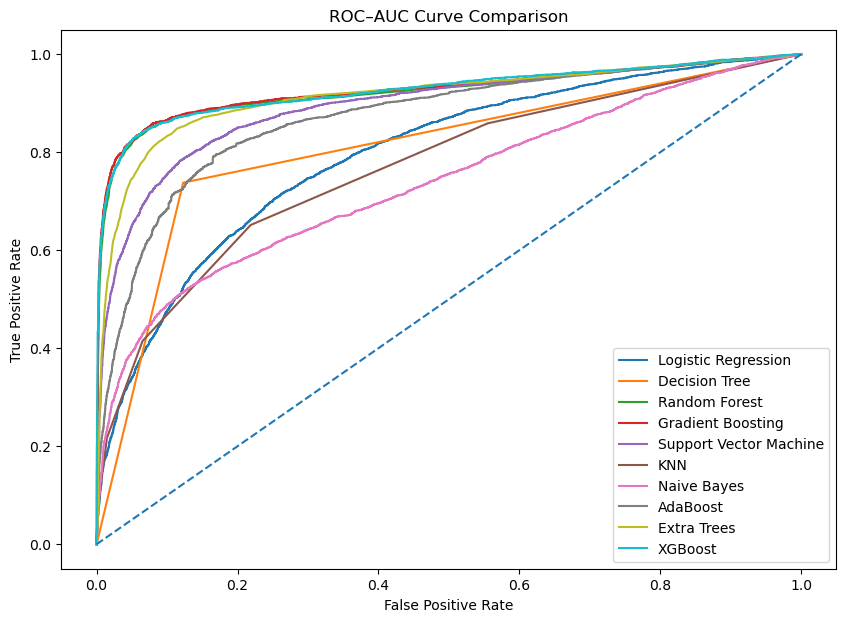

In [59]:
plt.figure(figsize=(10,7))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve Comparison")
plt.legend()
plt.show()

In [60]:
rf = models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

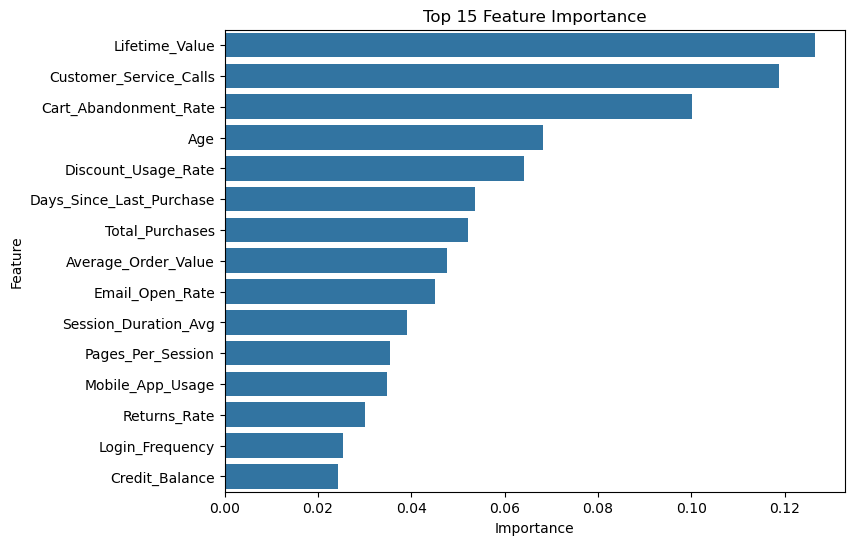

In [61]:
plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance.head(15))
plt.title("Top 15 Feature Importance")
plt.show()

In [62]:
best_model = models["XGBoost"]

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      8888
           1       0.91      0.79      0.84      3612

    accuracy                           0.91     12500
   macro avg       0.91      0.88      0.89     12500
weighted avg       0.91      0.91      0.91     12500



In [63]:
best_model = models["Gradient Boosting"]

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      8888
           1       0.94      0.76      0.84      3612

    accuracy                           0.92     12500
   macro avg       0.92      0.87      0.89     12500
weighted avg       0.92      0.92      0.91     12500

